# Growth-rate review

Everything the `growth_review` package holds, and how the figures are built from it.

The package separates three things that get mixed together in growth plots and
should not be: published **measurements**, projected **forecast** precisions, and
tabulated **theory** curves. They never share a marker style here, because a
forecast bar sits exactly on the model curve by construction — a reader who takes
one for data concludes the model is confirmed at that precision.

## 1. What is in the package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import growth_review as gr

gr.use_style()
print(gr.summary_table())

name                             kind         probe        method  summary
--------------------------------------------------------------------------------------------------------------
bao_compilation                  measurement  bao          -       BAO distance measurements 2009-2020, 6dFGS through eBOSS DR16 + Lya.
bao_sdss_final                   measurement  bao          -       SDSS-family consensus BAO distance ratios.
fsigma8_pv                       measurement  fsigma8      pv      35 published fsigma8 values from peculiar-velocity data, one row per measurement, with asymmetric errors, method family and full provenance.
fsigma8_rsd                      measurement  fsigma8      rsd     Galaxy-clustering (RSD) fsigma8, 2dF through DESI DR1 full shape.
fsigma8_sdss_final               measurement  fsigma8      rsd     fsigma8 as quoted in the SDSS final cosmology paper, with z ranges.
s8_weak_lensing                  measurement  s8           -       S8 from cosmic shear: DES

Each entry carries its own caveats. These are not decoration — they are the
things that make a number wrong if ignored.

In [2]:
for name in ["fsigma8_pv", "fsigma8_rsd", "fsigma8_sn_pv", "cola_growth_fr"]:
    d = gr.get(name)
    print(f"\n{d.name}  [{d.kind} / {d.probe}]  {d.source}")
    for c in d.caveats:
        print("   ! " + c)


fsigma8_pv  [measurement / fsigma8]  compiled 2026-08-13/14; every row traced to its own paper
   ! Rows are NOT independent: 6dFGSv, SDSS PV, SFI++, 2MTF and 2M++ recur across most of them, and CF3/CF4 contain several. Never average.
   ! The four DESI_DR1_* rows are three correlated estimators on one dataset plus their consensus; load_fsigma8() keeps only the consensus by default.
   ! Six rows normalise to the LINEAR sigma8 (sigma8_norm='lin'); Carrick et al. quote both for the same data and they differ by 6.5%.
   ! method_family='vd_dynamical' is declared and EMPTY: every published velocity-density comparison predicts the velocity field with linear dynamics. The particle-evolving analyses (Valade+2026, Manticore, Boruah-Lavaux-Hudson 2022, Graziani+2019) publish reconstructions, not a growth rate. See methods.EMPTY_FAMILY_EVIDENCE.
   ! 'Forward model' in Boubel2024, Stiskalek2026, Boruah2020 and Stahl2021 means the DISTANCE INDICATOR, not the field dynamics -- Stiskalek's abstra

## 2. One tidy frame for every fsigma8 constraint

In [3]:
df = gr.load_fsigma8()
print(df.groupby(["kind", "method"]).size().to_string())
df.head(8)

kind         method
forecast     pv        36
             rsd       32
measurement  pv        28
             rsd       25


,key,ref,label,survey,year,z,value,err_lo,err_hi,frac_err,kind,probe,method,dataset,method_family,fit_technique,sigma8_norm,provenance
0,Johnson2014,Johnson et al.,6dFGSv,NaN,2014.0,0.000,0.418,0.065,0.065,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src
1,Howlett2017,Howlett et al.,2MTF,NaN,2017.0,0.000,0.510,0.080,0.090,NaN,measurement,fsigma8,pv,fsigma8_pv,two_point,likelihood,unstated,src
2,AdamsBlake2017,Adams & Blake,6dFGS,NaN,2017.0,0.000,0.424,0.064,0.067,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src
3,LilowNusser2021,Lilow & Nusser,CF3+2MRS,NaN,2021.0,0.013,0.367,0.060,0.060,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,likelihood,lin,src
4,Boubel2024,Boubel et al.,Tully-Fisher forward model,NaN,2024.0,0.017,0.350,0.030,0.030,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,forward_model,unstated,src
5,Davis2011,Davis et al.,SFI++,NaN,2011.0,0.020,0.310,0.040,0.040,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,chi2,unstated,der
6,Carrick2015,Carrick et al.,2M++,NaN,2015.0,0.020,0.401,0.024,0.024,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,chi2,lin,der
7,Huterer2017,Huterer et al.,low-z SNe + galaxy velocities,NaN,2017.0,0.020,0.428,0.045,0.048,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src


Four peculiar-velocity rows have no effective redshift. That is not a gap in the
compilation: the authors assign none (Stiskalek's Table 1 prints "—" for the
joint TFR+SNe fit, Stahl quotes none, Wang frames the analysis in survey depth).
They have no position on an fsigma8(z) axis, so they are dropped rather than
placed at a redshift nobody published.

In [4]:
gr.io.dropped_without_z()[["key", "ref", "value", "err_lo", "err_hi"]]

,key,ref,value,err_lo,err_hi
0,Stahl2021,Stahl et al.,0.390,0.022,0.022
1,Stiskalek2026,Stiskalek,0.412,0.018,0.018
2,Wang2026_group,Wang et al.,0.384,0.194,0.116
3,Wang2026_local,Wang et al.,0.569,0.060,0.054


## 3. The fiducial cosmology

In [5]:
cosmo = gr.FlatLCDM()
z = np.array([0.0, 0.07, 0.5, 1.0, 1.5])
for zi in z:
    print(f"z={zi:4.2f}   f={cosmo.growth_rate(zi):.4f}   "
          f"Om(z)^0.55={cosmo.omega_m_z(zi)**0.55:.4f}   "
          f"fsigma8={cosmo.fsigma8(zi):.4f}")

z=0.00   f=0.5260   Om(z)^0.55=0.5286   fsigma8=0.4266
z=0.07   f=0.5674   Om(z)^0.55=0.5693   fsigma8=0.4435
z=0.50   f=0.7601   Om(z)^0.55=0.7598   fsigma8=0.4742
z=1.00   f=0.8761   Om(z)^0.55=0.8755   fsigma8=0.4315
z=1.50   f=0.9309   Om(z)^0.55=0.9305   fsigma8=0.3745


f is integrated, not approximated by Omega_m(z)^0.55 — the approximation is good
to about 0.5% at z = 0, and assuming the GR growth index is exactly what a
growth review must not do silently. `fsigma8_gamma` gives the approximation when
you want it as a comparison curve.

## 4. Linear, log, or both

The compilation spans z = 0 to z = 1.5. Peculiar velocities live below z = 0.1
and clustering above it, so no single scale serves both. Four are available;
this is what each does to the same data.

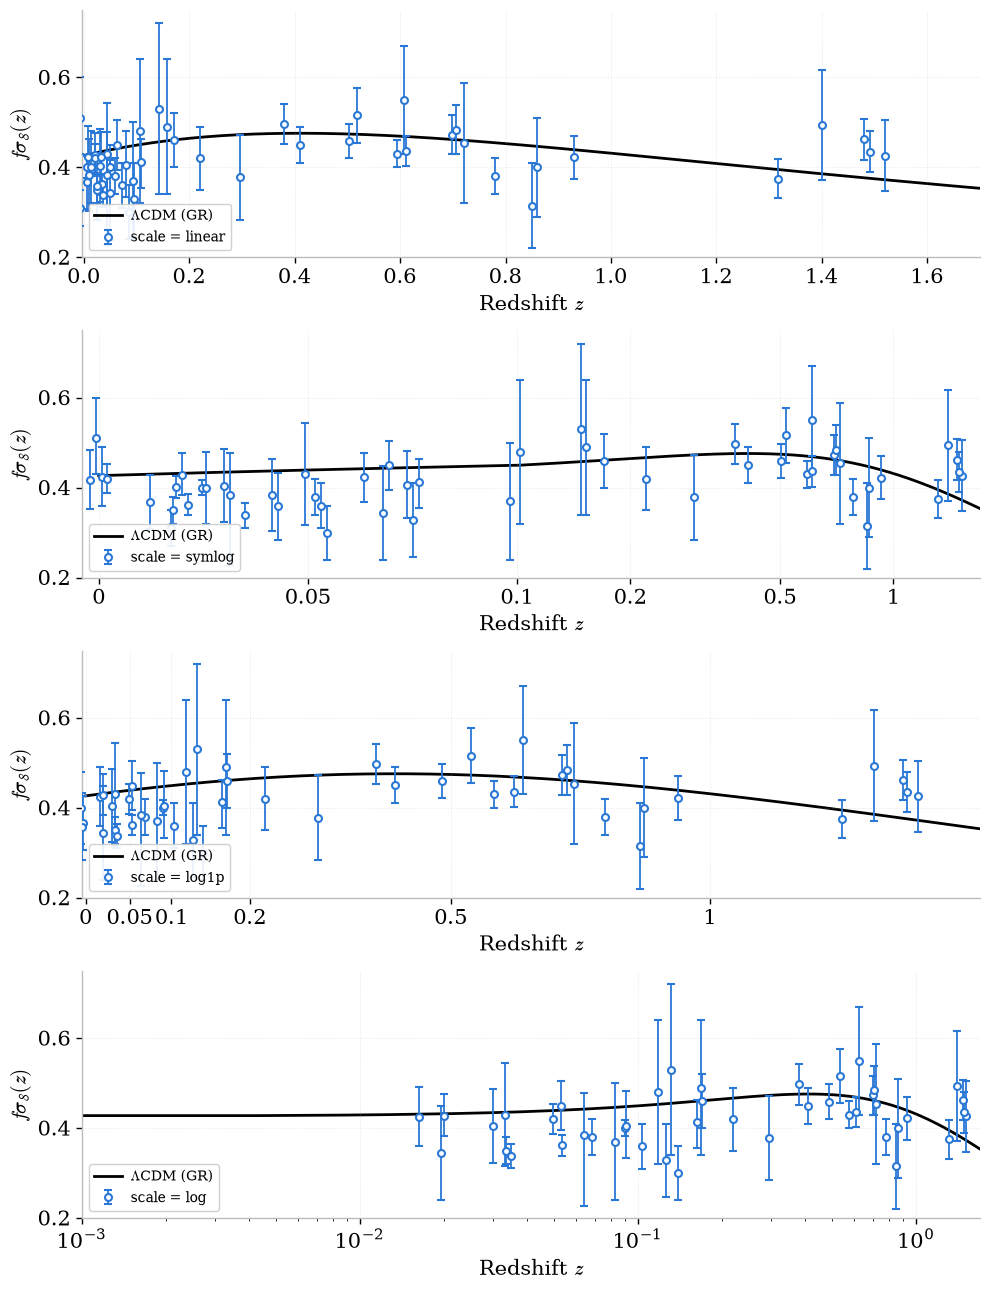

In [6]:
meas = gr.load_fsigma8(kind="measurement")

fig, axes = plt.subplots(4, 1, figsize=(10, 13))
for ax, scale in zip(axes, ["linear", "symlog", "log1p", "log"]):
    gr.plotting.plot_reference(ax, cosmo, zmax=1.7)
    x = gr.dodge_x(meas["z"].to_numpy(), min_sep=0.006, step=0.014, scale=scale)
    gr.plotting.plot_measurements(ax, meas, x=x, ms=5, color=gr.PALETTE["blue"],
                                  label=f"scale = {scale}")
    lo = 1e-3 if scale == "log" else -0.004
    gr.style_axes(ax, xlim=(lo, 1.7), ylim=(0.2, 0.75), scale=scale,
                  legend_kw=dict(loc="lower left", fontsize=10))
fig.tight_layout()

- **linear** — every peculiar-velocity point is stacked in the first 5% of the axis.
- **symlog** — linear below z = 0.1, log above. z = 0 stays on the panel and each
  regime gets roughly half the width. This is the package default for mixed panels.
- **log1p** — log(1+z) also keeps z = 0, but 1+z only runs 1 → 1.1 across the whole
  PV range, so it barely helps.
- **log** — silently drops the six z = 0 rows. Never use it on a panel with PV data.

## 5. Peculiar velocities, by method

28 points; dropped for no z_eff: ['Stahl2021', 'Stiskalek2026', 'Wang2026_group', 'Wang2026_local']


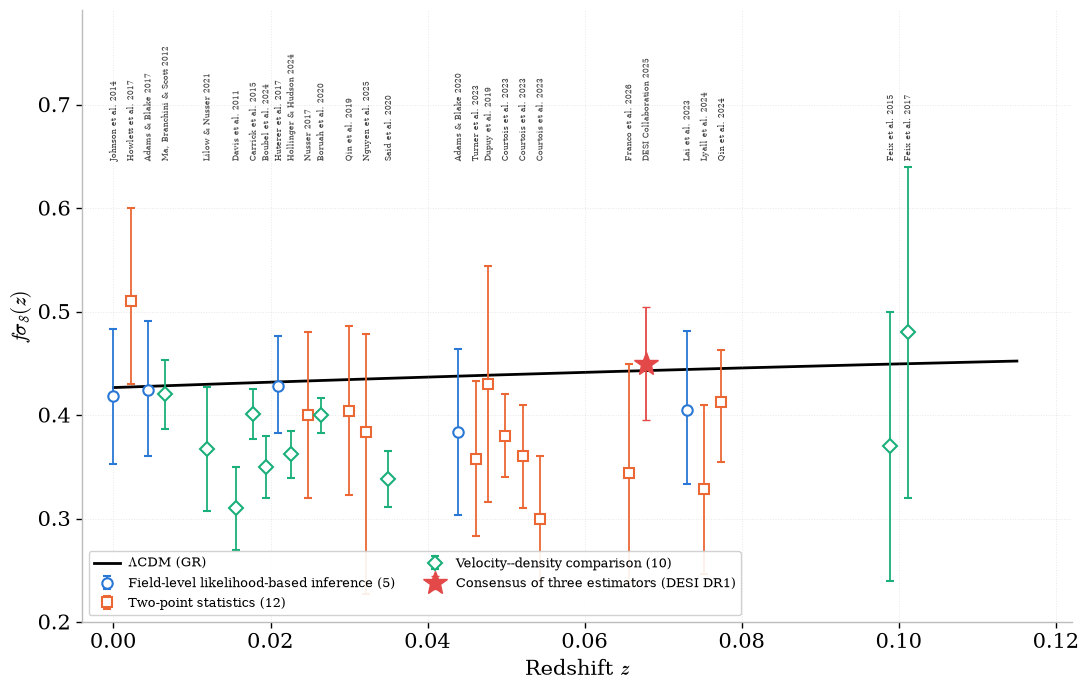

In [7]:
fig, meta = gr.figures.fig_pv()
print(f"{meta['n']} points; dropped for no z_eff: {meta['dropped_no_z']}")

Grouped by method rather than by survey deliberately. The compilation is
inhomogeneous — 6dFGSv, SDSS PV, SFI++, 2MTF and 2M++ recur across most rows and
CF3/CF4 *contain* several of them — so a per-survey legend would suggest an
independence that is not there. What does vary meaningfully is how the velocity
field is compressed before fitting.

Every assignment carries the sentence from its own paper that fixes it:

In [8]:
print(gr.evidence_report())


Field-level likelihood-based inference  (6)
  The likelihood of the observed density and velocity FIELD VALUES is written through a model covariance and maximised or sampled. No intermediate summary statistic is measured.
    Johnson2014              'The covariance matrix of the data'; 'P(m|d) ~ L'; the velocity field is modelled as a Gaussian random field.
    AdamsBlake2017           Lai et al. 2023: 'In the development of the maximum likelihood fields method, Adams & Blake (2017) were the first to simultaneously model...'
    Huterer2017              Section headings 'Peculiar velocity covariance' / 'Likelihood Analysis'; fits the amplitude of the signal covariance.
    AdamsBlake2020           'auto-covariance models of both probes in a fully self-consistent, maximum-likelihood method'
    DESI_DR1_maxlike         'using the maximum likelihood fields method'
    Lai2023                  'we focus on the maximum likelihood fields method to constrain the growth rate of structure'



## 6. Galaxy clustering

\caption{Measurements of $f\sigma_8(z)$ from galaxy clustering (redshift-space distortions), compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). Points are coloured by survey; DESI~DR1 full-shape results are shown in red and labelled by tracer sample. Points at nearly coincident redshifts are displaced horizontally for legibility.}


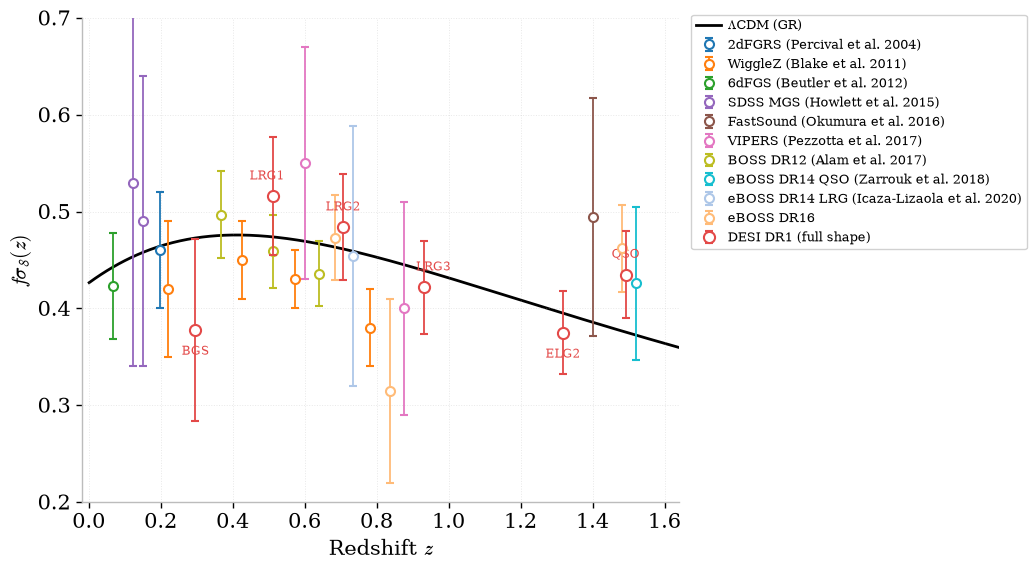

In [9]:
fig, meta = gr.figures.fig_rsd()
print(meta["caption"])

## 7. Everything at once

28 PV + 25 RSD points


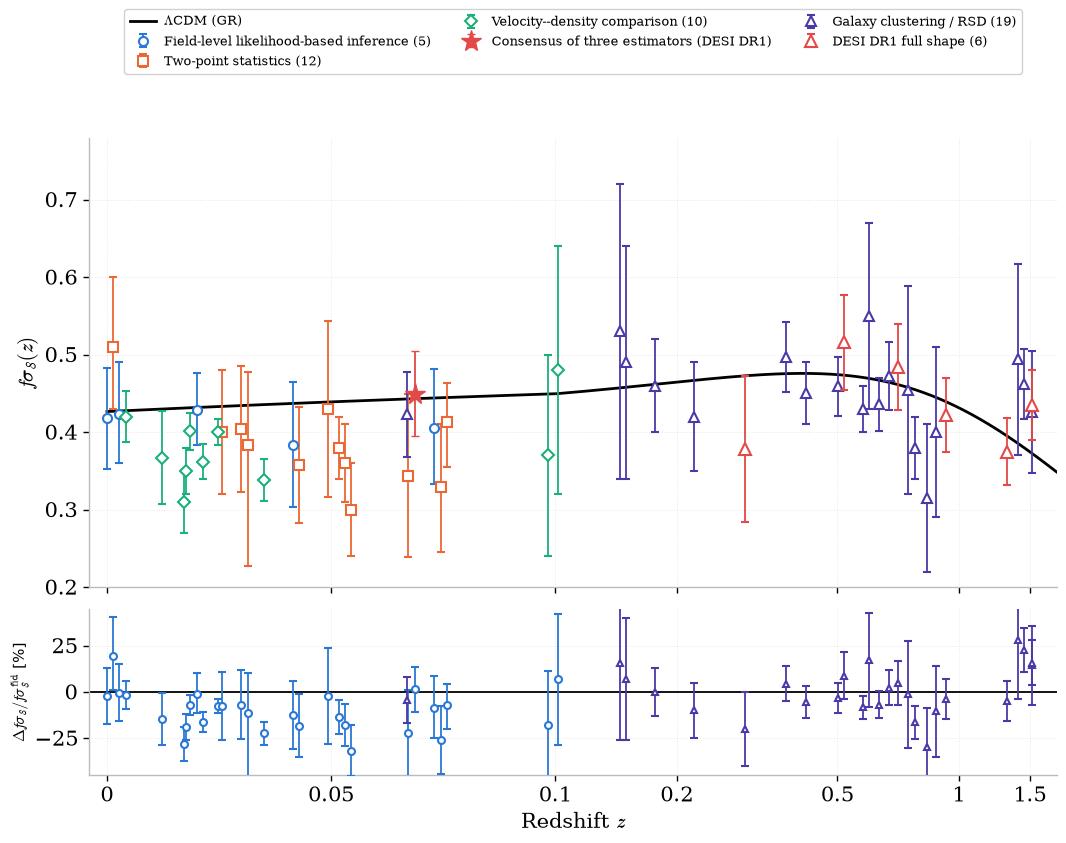

In [10]:
fig, meta = gr.figures.fig_overview()
print(f"{meta['n_pv']} PV + {meta['n_rsd']} RSD points")

## 8. Forecasts

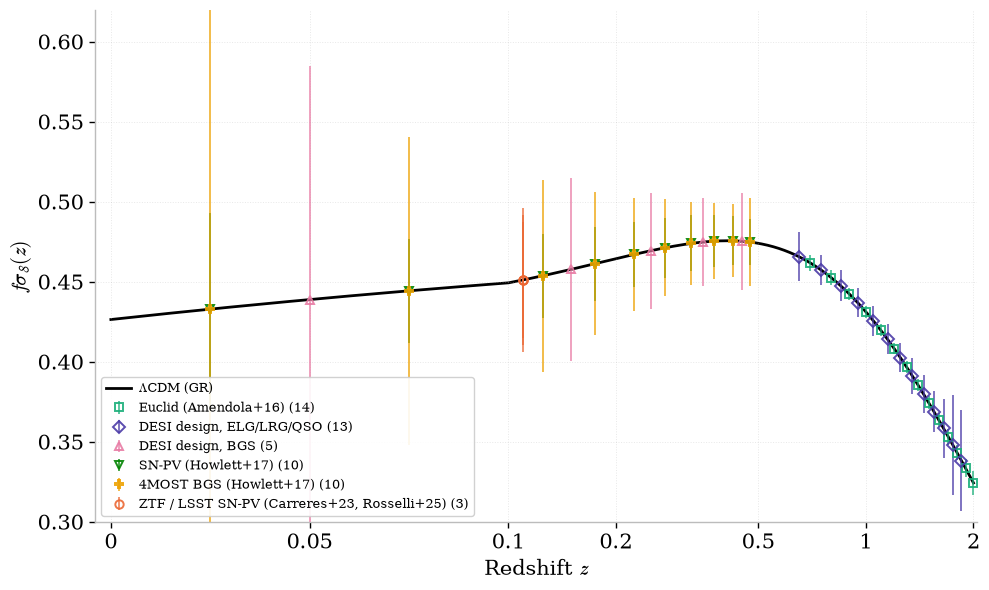

In [11]:
fig, meta = gr.figures.fig_forecasts()

## 9. Theory curves

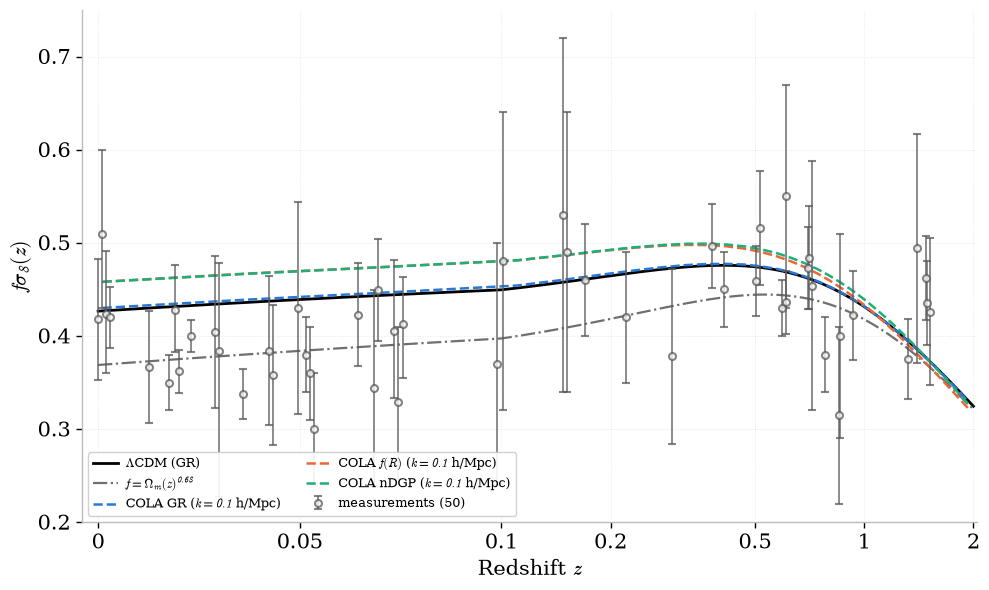

In [12]:
fig, meta = gr.figures.fig_theory(k=0.1)

The COLA GR curve lands on the package's own LCDM prediction, which is the check
that the tabulated growth is being read and normalised correctly. In f(R) the
growth rate is scale dependent, so the curve is an effective fsigma8 at one k
and not the model's growth rate — vary `k` to see how much that matters.

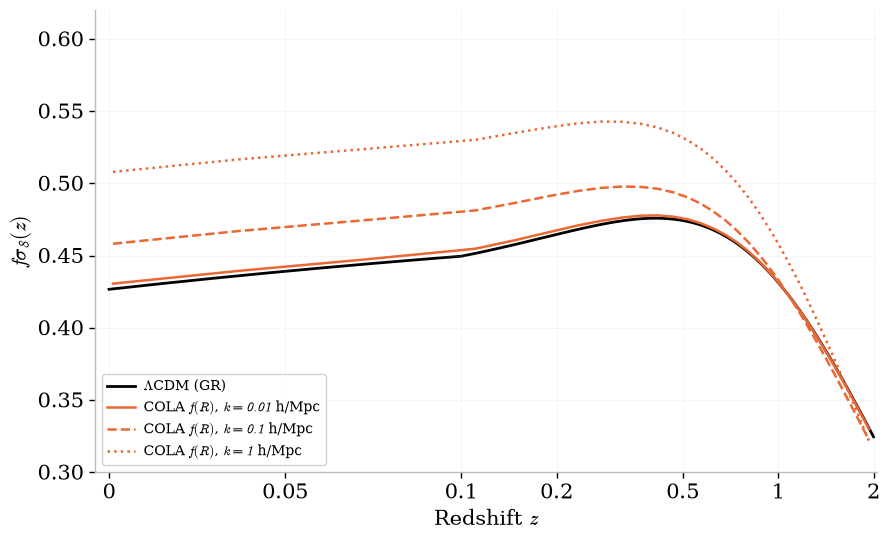

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
gr.plotting.plot_reference(ax, cosmo, zmax=2.0)
for k, ls in [(0.01, "-"), (0.1, "--"), (1.0, ":")]:
    gr.plotting.plot_theory(ax, "cola_growth_fr", sigma8=cosmo.sigma8, k=k,
                            zmax=2.0, ls=ls, color=gr.PALETTE["orange"],
                            label=rf"COLA $f(R)$, $k={k:g}$ h/Mpc")
gr.style_axes(ax, xlim=(-0.004, 2.05), ylim=(0.3, 0.62), scale="symlog",
              legend_kw=dict(loc="lower left", fontsize=10))
fig.tight_layout()

## 5b. Method families, and the one that is empty

Peculiar-velocity results are grouped by *what the estimator does to the data
before fitting*, not by what optimiser it runs afterwards — almost every analysis
maximises a likelihood somewhere.

The velocity–density family is split on the **dynamics of the prediction**:
`vd_linear` predicts the velocity field by linear theory (directly, or through a
Wiener filter / constrained realisation — still linear dynamics), while
`vd_dynamical` would evolve a particle field through a gravity solver. The second
is **empty**, and that is the result, not an oversight.

Watch the word "forward model": in Boubel 2024, Stiskalek 2026, Boruah 2020 and
Stahl 2021 it means the *distance indicator*, not the field dynamics.

In [14]:
from growth_review.methods import EMPTY_FAMILY_EVIDENCE, FORWARD_MODEL_IS_THE_INDICATOR

print("Declared but empty -- vd_dynamical:")
for author, arxiv, why in EMPTY_FAMILY_EVIDENCE["vd_dynamical"]:
    print(f"  {author:<30} arXiv:{arxiv:<12} {why}")
print()
print("'Forward model' meaning the distance indicator, not the dynamics:")
for k, why in FORWARD_MODEL_IS_THE_INDICATOR.items():
    print(f"  {k:<16} {why}")

Declared but empty -- vd_dynamical:
  Graziani et al. 2019           arXiv:1901.01818   hierarchical Bayesian forward model of CF3, but 'assumes the LCDM model within the linear regime'; no fsigma8 quoted
  Boruah, Lavaux & Hudson 2022   arXiv:2111.15535   'a forward-modelled velocity field reconstruction algorithm'; the forward model is of the distance data and Malmquist bias, and no fsigma8 value is reported
  Valade et al. 2026             arXiv:2602.03699   'The dynamics are integrated with a particle-mesh gravity solver, thus probing the mildly non-linear regime' on CF4 -- the one clear particle-evolving analysis, and it reports no fsigma8
  Manticore-Local                arXiv:2505.10682   BORG with a nonlinear gravitational solver on 2M++; reports Bayesian evidence comparisons, not a growth rate

'Forward model' meaning the distance indicator, not the dynamics:
  Boubel2024       forward-models the Tully-Fisher relation; the velocity field is the 2M++ linear-theory prediction
  

## 10. Citations

**The package holds no BibTeX keys.** They belong to a manuscript, not to a data
compilation, so they live here instead — and they are not typed by hand either.
The compilation carries an `arxiv` column, so the mapping is *derived* from the
`.bib` by matching arXiv identifiers: it self-updates when the bibliography grows
and cannot silently drift out of date.

Read `arxiv` as a string. pandas will otherwise parse it as a float and eat the
trailing zero of `1706.05130`.

In [15]:
import re
from pathlib import Path
import pandas as pd

BIB = Path("~/Documents/Python/Packages/overleaf/"
           "6a43ba00166d744d7802db95/bibli_hdr_0.bib").expanduser()

ARXIV_PAT = r"(?:arxiv\.org/abs/|arXiv:)\s*([\w.\-/]+?)(?:v\d+)?(?=[\s\},\]]|$)"


def arxiv_index(bib_path):
    """{normalised arXiv id: [bibkey, ...]} for every entry that names one."""
    text = Path(bib_path).read_text(encoding="utf-8", errors="replace")
    idx = {}
    for m in re.finditer(r"@\w+\{([^,]+),", text):
        key, start = m.group(1).strip(), m.start()
        nxt = text.find("\n@", start + 1)
        body = text[start: nxt if nxt > 0 else len(text)]
        for a in set(re.findall(ARXIV_PAT, body, re.I)):
            idx.setdefault(a.lower().rstrip("."), []).append(key)
    return idx


def build_bibkey(bib_path, overrides=None):
    """Map compilation row key -> bibkey(s) by arXiv match; report the rest."""
    idx = arxiv_index(bib_path)
    pv = pd.read_csv(gr.get("fsigma8_pv").full_path, comment="#",
                     dtype={"arxiv": str})
    mapping, unmatched, ambiguous = {}, [], {}
    for _, r in pv.iterrows():
        hits = idx.get(str(r["arxiv"]).strip().lower(), [])
        if not hits:
            unmatched.append((r["key"], r["authors"], r["year"], r["arxiv"]))
        else:
            if len(hits) > 1:
                ambiguous[r["key"]] = hits
            mapping[r["key"]] = ",".join(hits)
    mapping.update(overrides or {})
    return mapping, unmatched, ambiguous

Two things the automatic pass cannot do, and reports rather than guesses:

- **entries whose bib record carries no arXiv identifier** — they are in the
  bibliography but there is nothing to match on, so they need one line each;
- **several bib entries sharing one arXiv identifier** — a duplicate, surfaced
  instead of silently picking a winner.

In [16]:
# Filled from the reported `unmatched` list, verified by title against the bib.
# Rows absent from both have no entry in bibli_hdr_0.bib at all and stay
# uncited -- they are outside the manuscript's citation set, not an error.
OVERRIDES = {
    "Said2020": "said_joint_2020",
    "Qin2024": "qin_redshift-space_2025",             # Momentum PS III, SDSSv
    "DESI_DR1_corrfunc": "turner_desi_2026",
    "DESI_DR1_consensus": "lai_desi_2026,turner_desi_2026,qin_desi_2025",
    # Boubel needed an override until 2026-08-14, when the duplicate
    # `boubel_cosmic_2023` entry (same arXiv:2301.12648 as the MNRAS article)
    # was removed from the bibliography. It now matches automatically.
}

# RSD rows carry no arXiv column, so they stay explicit. eBOSS DR16 and DESI DR1
# each have two companion papers, both cited.
RSD_BIBKEY = {
    "Percival/2dF": "percival_2df_2004",
    "Blake/WiggleZ": "blake_wigglez_2011",
    "Beutler/6dFGS": "beutler_6df_2012",
    "Howlett/MGS": "howlett_clustering_2015",
    "Okumura/FastSound": "okumura_subaru_2016",
    "Pezzotta/VIPERS": "pezzotta_vimos_2017",
    "eBOSS/DR16_LRG": "bautista_completed_2020,gil-marin_completed_2020",
    "eBOSS/DR16_ELG": "tamone_completed_2020,mattia_completed_2020",
    "eBOSS/DR16_QSO": "hou_completed_2020,neveux_completed_2020",
    **{f"DESI-Y1/{s}": "adame_desi_2025,collaboration_desi_2025-2"
       for s in ["BGS", "LRG1", "LRG2", "LRG3", "ELG2", "QSO"]},
}

BIBKEY, unmatched, ambiguous = build_bibkey(BIB, OVERRIDES)
BIBKEY.update(RSD_BIBKEY)

print(f"{len(BIBKEY)} rows mapped")
if ambiguous:
    print("\nAMBIGUOUS -- one arXiv id, several bib entries:")
    for k, v in ambiguous.items():
        print(f"  {k:<24} {v}")
if unmatched:
    print("\nNo arXiv match in the bib (override above, or leave uncited):")
    for key, auth, yr, ax in unmatched:
        print(f"  {key:<24} {auth} {yr}   arXiv:{ax}"
              + ("   [overridden]" if key in OVERRIDES else ""))

46 rows mapped

No arXiv match in the bib (override above, or leave uncited):
  Nusser2017               Nusser 2017   arXiv:1703.05324
  Said2020                 Said et al. 2020   arXiv:2007.04993   [overridden]
  DESI_DR1_corrfunc        Turner et al. (DESI) 2025   arXiv:2512.03230   [overridden]
  DESI_DR1_consensus       DESI Collaboration 2025   arXiv:2512.03230   [overridden]
  Qin2024                  Qin et al. 2024   arXiv:2411.09571   [overridden]
  Feix2015                 Feix et al. 2015   arXiv:1503.05945
  Feix2017                 Feix et al. 2017   arXiv:1612.07809
  MaBranchiniScott2012     Ma, Branchini & Scott 2012   arXiv:1205.4237


### The HDR figures

`cited_only=True` restricts a figure to rows the mapping covers, so the panels
show exactly the set the text cites. Whatever is plotted but uncitable comes back
in `meta["missing_citations"]` — a figure with a non-empty list there is not
finished.

pv: 24 points plotted -> ../figures/hdr/growth_pv.pdf
dropped, no bibliography entry (4): Feix2015, Feix2017, MaBranchiniScott2012, Nusser2017
uncitable: none

\caption{Measurements of $f\sigma_8$ from peculiar velocities at $z<0.1$, compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). The compilation is inhomogeneous --- the measurements share data and differ in normalisation --- so points are grouped by the method used to extract $f\sigma_8$ rather than by survey: field-level likelihood-based inference~\cite{johnson_6df_2014,adams_improving_2017,huterer_testing_2017,adams_joint_2020,lai_using_2022}; two-point statistics~\cite{howlett_2mtf_2017,qin_redshift_2019,turner_local_2022,dupuy_estimation_2019,courtois_gravity_2023,franco_measuring_2026,lyall_constraining_2024,qin_redshift-space_2025,nguyen_detection_2026}; velocity--density comparison~\cite{lilow_constrained_2021,boubel_large-scale_2024,davis_local_2011,carrick_cosmological_2015,holling

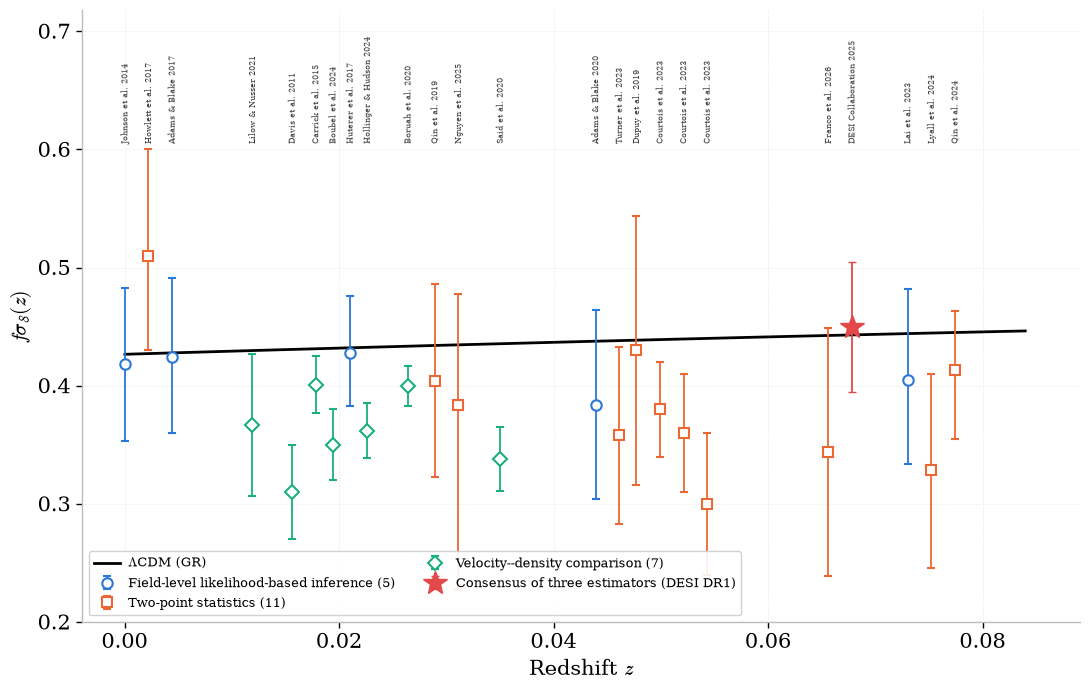

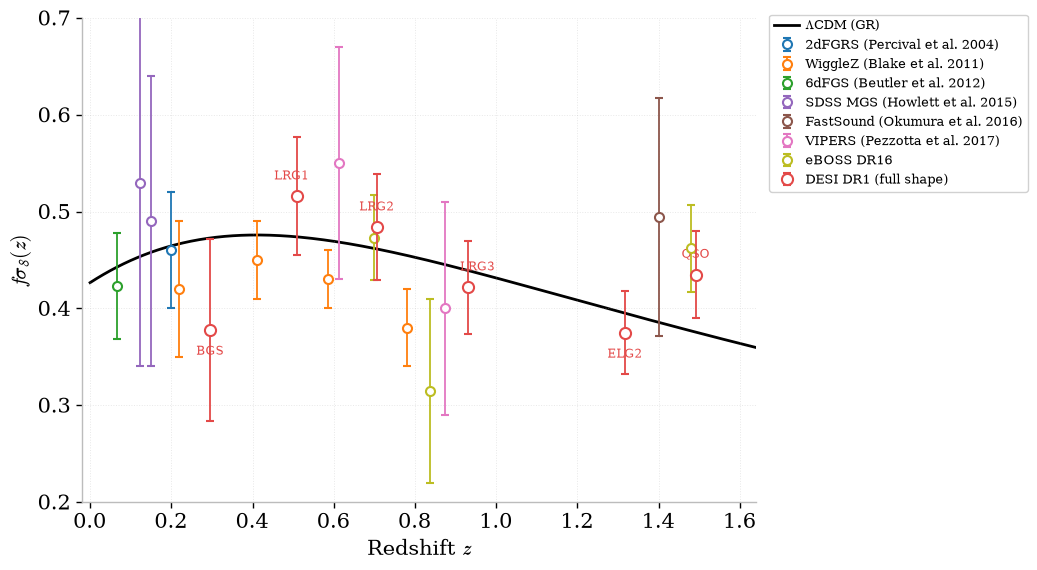

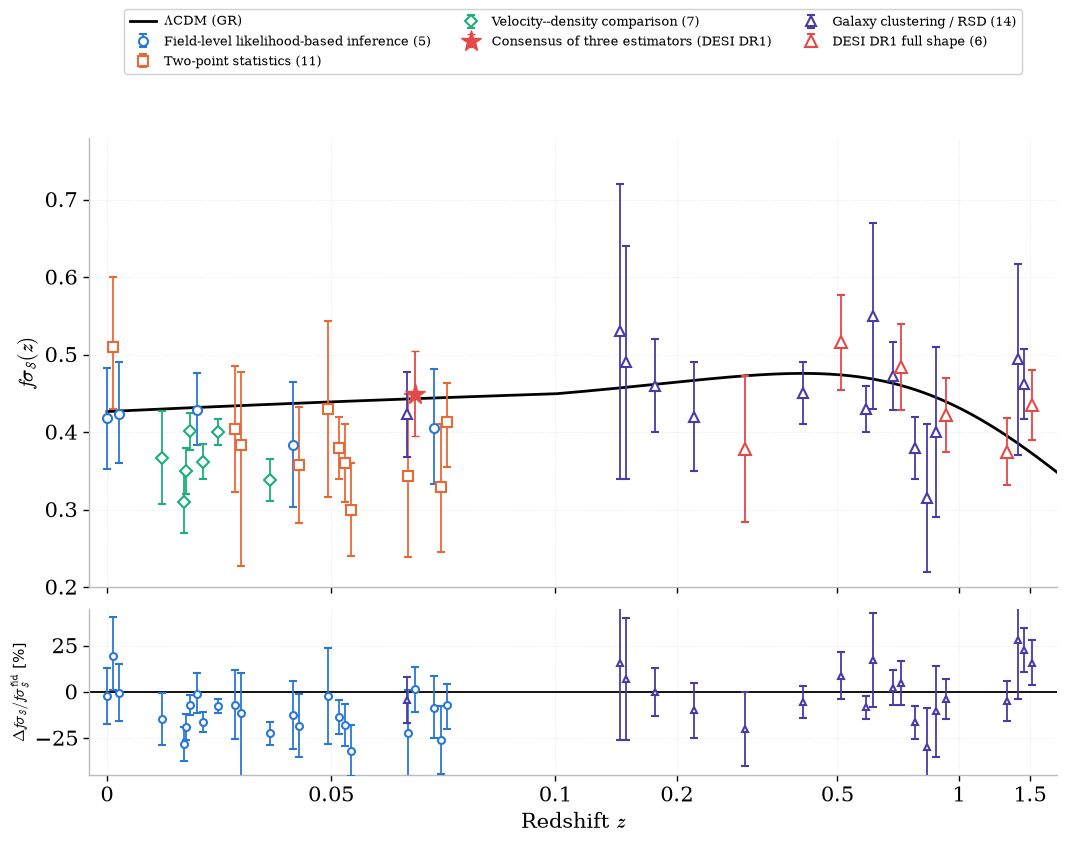

In [17]:
HDR_DIR = Path("../figures/hdr")
HDR_DIR.mkdir(parents=True, exist_ok=True)

for name in ["pv", "rsd", "overview"]:
    fig, meta = gr.figures.FIGURES[name](bibkey=BIBKEY, cited_only=True)
    fig.savefig(HDR_DIR / f"growth_{name}.pdf", bbox_inches="tight")
    print("=" * 78)
    print(f"{name}: {len(meta['plotted'])} points plotted "
          f"-> {HDR_DIR / f'growth_{name}.pdf'}")
    if meta["dropped"]:
        print(f"dropped, no bibliography entry ({len(meta['dropped'])}): "
              + ", ".join(meta["dropped"]))
    print("uncitable:", meta["missing_citations"] or "none")
    print()
    print(meta["caption"])
    print()

## 11. Writing every figure to disk

From the shell:

```bash
growth-review-figures --outdir figures
growth-review-figures --only pv rsd --format png
```

The CLI writes uncited captions — it has no bibliography to work from. Build the
cited versions from section 10 above, which is where the manuscript's keys live.

## 12. Caption citation lists

Ready to paste. For each figure: the points grouped by method family with the
BibTeX key beside each one so the grouping can be checked by eye, then the
single `\cite{...}` for that group, then one combined `\cite{...}` in redshift
order for a plain "measurements are taken from…" sentence.

In [18]:
from growth_review.methods import FAMILY_LABEL, FAMILY_ORDER


def citation_block(name, bibkey, **kw):
    """Grouped, ready-to-paste citation listing for one figure."""
    import matplotlib.pyplot as plt
    fig, meta = gr.figures.FIGURES[name](bibkey=bibkey, cited_only=True, **kw)
    plt.close(fig)
    df = meta["plotted"]

    out = [f"% {'=' * 72}",
           f"% {name.upper()} figure -- {len(df)} measurements, "
           f"{'all cited' if not meta['missing_citations'] else 'UNCITED POINTS'}"]

    if "method_family" in df and df["method_family"].notna().any():
        groups = [(FAMILY_LABEL[f], df[df["method_family"] == f])
                  for f in FAMILY_ORDER if (df["method_family"] == f).any()]
    else:
        groups = [(survey, df[df["survey"] == survey])
                  for survey in dict.fromkeys(df["survey"])]

    for label, sub in groups:
        out.append(f"%\n% {label} ({len(sub)})")
        for _, r in sub.sort_values("z").iterrows():
            year = "" if pd.isna(r["year"]) else f" {int(r['year'])}"
            out.append(f"%   {r['ref'] + year:<32} {bibkey.get(r['key'], '??')}")
        keys = dict.fromkeys(k for _, r in sub.sort_values("z").iterrows()
                             for k in bibkey[r["key"]].split(","))
        out.append(r"\cite{" + ",".join(keys) + "}")

    allkeys = dict.fromkeys(k for _, r in df.sort_values("z").iterrows()
                            for k in bibkey[r["key"]].split(","))
    out += ["%", "% all of the above, in redshift order:",
            r"\cite{" + ",".join(allkeys) + "}", ""]
    return "\n".join(out)


for name in ["pv", "rsd", "overview"]:
    print(citation_block(name, BIBKEY))

% ========================================================================
% PV figure -- 24 measurements, all cited
%
% Field-level likelihood-based inference (5)
%   Johnson et al. 2014              johnson_6df_2014
%   Adams & Blake 2017               adams_improving_2017
%   Huterer et al. 2017              huterer_testing_2017
%   Adams & Blake 2020               adams_joint_2020
%   Lai et al. 2023                  lai_using_2022
\cite{johnson_6df_2014,adams_improving_2017,huterer_testing_2017,adams_joint_2020,lai_using_2022}
%
% Two-point statistics (11)
%   Howlett et al. 2017              howlett_2mtf_2017
%   Qin et al. 2019                  qin_redshift_2019
%   Nguyen et al. 2025               nguyen_detection_2026
%   Turner et al. 2023               turner_local_2022
%   Dupuy et al. 2019                dupuy_estimation_2019
%   Courtois et al. 2023             courtois_gravity_2023
%   Courtois et al. 2023             courtois_gravity_2023
%   Courtois et al. 2023       

## 13. What this review leaves out

Four distinct exclusions, and they are not interchangeable — a reader who sees a
short compilation should be able to find out exactly what was dropped and why.

In [19]:
import re

pv_raw = pd.read_csv(gr.get("fsigma8_pv").full_path, comment="#",
                     dtype={"arxiv": str})

# 1. never entered the compilation -- read from the data file's own warning 9,
#    so this cannot drift away from the file it describes
header = gr.get("fsigma8_pv").full_path.read_text().splitlines()
w9 = [l for l in header
      if l.startswith("#") and re.match(r"#\s*9\.", l)]
i = header.index(w9[0])
j = next(k for k in range(i + 1, len(header)) if re.match(r"#\s*1[0-9]\.", header[k]))
print("1. REMOVED FROM THE COMPILATION -- not peculiar-velocity measurements")
for line in header[i:j]:
    print("  " + line.lstrip("#").strip())

# 2. in the compilation, dropped from the figures for want of an x position
print("\n2. NO AUTHOR-ASSIGNED EFFECTIVE REDSHIFT -- in the data, off the plot")
for _, r in gr.io.dropped_without_z().iterrows():
    print(f"  {r['key']:<24} {r['ref']} {int(r['year'])}   "
          f"{r['value']:.3f} +{r['err_hi']:.3f}/-{r['err_lo']:.3f}")

# 3. folded into the consensus rather than plotted as independent points
print("\n3. FOLDED INTO THE DESI DR1 CONSENSUS -- correlated, one dataset")
for _, r in pv_raw[pv_raw["key"].str.startswith("DESI_DR1_")].iterrows():
    if r["key"] != "DESI_DR1_consensus":
        print(f"  {r['key']:<24} {r['authors']} {r['year']}   "
              f"{r['fsigma8']:.3f}   {r['estimator']}")

# 4. plotted only in the full compilation: no entry in the bibliography
print("\n4. NO ENTRY IN bibli_hdr_0.bib -- dropped by cited_only=True")
for name in ["pv", "rsd"]:
    fig, meta = gr.figures.FIGURES[name](bibkey=BIBKEY, cited_only=True)
    plt.close(fig)
    print(f"  [{name}]")
    for k in meta["dropped"]:
        row = pv_raw[pv_raw["key"] == k]
        extra = (f"   {row['authors'].iloc[0]} {row['year'].iloc[0]}, "
                 f"arXiv:{row['arxiv'].iloc[0]}") if len(row) else ""
        print(f"    {k}{extra}")

1. REMOVED FROM THE COMPILATION -- not peculiar-velocity measurements
  9. REMOVED 2026-08-13, out of scope -- redshift-space distortions of the 6dFGS
  *redshift* survey, no measured distances, therefore not peculiar-velocity
  measurements. Recorded here so the difference from Turner (2024) Table 1,
  which carries all four, is explicit:
  Achitouv+2017 galaxy-galaxy   0.42 +/- 0.06   1606.03092
  Achitouv+2017 void-galaxy     0.39 +/- 0.11   1606.03092  (shares galaxies
  with the row above)
  Beutler+2012                  0.423 +/- 0.055 1204.4725
  Blake, Carter & Koda 2018     0.38 +/- 0.12   1801.04969
  
  

2. NO AUTHOR-ASSIGNED EFFECTIVE REDSHIFT -- in the data, off the plot
  Stahl2021                Stahl et al. 2021   0.390 +0.022/-0.022
  Stiskalek2026            Stiskalek 2026   0.412 +0.018/-0.018
  Wang2026_group           Wang et al. 2026   0.384 +0.116/-0.194
  Wang2026_local           Wang et al. 2026   0.569 +0.054/-0.060

3. FOLDED INTO THE DESI DR1 CONSENSUS -- c